In [ ]:
#CSC 4730: Data Visualization 
#Final Project 
#Angel Williams 

#Dataset Summary: This dataset simulates real-world smart farming operations powered by IoT sensors and satellite data. 
# It captures environmental and operational variables that affect crop yield across 500 farms located in regions like India, the USA, and Africa.

#Question: Do the majority of the five crop types planted within the USA experience both crop disease status of mild or lower and higher than average yield per hectare 
#when an at or above average amount of pesticides have been applied to the crop?

#---

#Hypothesis Testing:
#H0 - the conservative approach. 
# Pesticides are defined by the EPA as Any substance or mixture of substances intended for preventing, destroying, repelling, or mitigating any pest. 
# https://www.epa.gov/minimum-risk-pesticides/what-pesticide 
# The USDA asserts that damage from pests can often result in "adverse impacts...[such as]:...Damage to crops...[and] Disease and quality of life impacts in populated areas. 
# https://www.nifa.usda.gov/topics/pest-management


#H0: Crops grown within the United States do experience both: a crop yield that is at or above the average and a crop disease status of mild or lower (None), when pesticide usage levels are at or above the United States’ average usage level
#HA: Crops grown within the United States do not experience both: a crop yield that is at or above the average and a crop disease status of mild or lower (None), when pesticide usage levels are at or above the United States’ average usage level



#Since the sample size is above 30 I will be using the z-score method and t-test while observing the difference of means of rates of crop disease and yield per hectare.
#I believe this is the best method because I am obersving 1 sample with n > 30 with 3 variables. I did not choose linear regression because x is catagorical which is not suitable for the assumption of Linearity principle. 
#I will not be using ANOVA because I do not have 3 or more samples to comapre. 
#Since I am using one sample of crops and I will retrieve my population mean from governmetn sourced information
#I have a normal/large sized sample that is independent with inference on the means and a knwonw population variance which fits the requirements of the Z test 
#---

In [237]:
#Component 1: Data Wrangling and Exploratory Data Visualization 
#Link to Dataset: https://www.kaggle.com/datasets/atharvasoundankar/smart-farming-sensor-data-for-yield-prediction

import pandas as pd 
import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
import statistics
import scipy.stats as stats
import numpy as np   


#Data Wrangling 
#Using pandas to import the .csv file 
df = pd.read_csv('Smart_Farming_Crop_Yield_2024.csv')
#Checking table 
#print (df.to_string())

#---

#Data Cleaning: 
#Dropping Unnecessary Columns: 
#soil_moisture, soil_pH, temperature_C, rainfall_mm, humidity_%, sunlight_hours, irrigation_type
#fertilizer_type, sowing_date, harvest_date, total_days, sensor_id, timestamp, latitude, longitude, NDVI_index
df_colDrop = df.drop(columns=['soil_moisture_%', 'soil_pH','temperature_C','rainfall_mm','humidity_%','sunlight_hours','irrigation_type','fertilizer_type','sowing_date','harvest_date','total_days','sensor_id','timestamp','latitude','longitude','NDVI_index'])


#filter results to USA
#existing record indluce: South USA, Central USA, 
df_stripped = df_colDrop
df_stripped['region'] = df_colDrop['region'].str.strip()
df_filtered = df_stripped
df_filtered=df_stripped[(df_stripped['region']=='South USA') | (df_stripped['region']=='Central USA')]
#203 results 

#Updating crop_disease_status Nulls to "None"
#Nulls and None indicate no disease present in the place 
df_Complete=df_filtered
df_Complete['crop_disease_status']= df_filtered['crop_disease_status'].fillna("None")
df_Complete #203 results 

/var/folders/25/7w50mjsn2jb48hvl9dv3ss840000gn/T/ipykernel_27017/1143443076.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Complete['crop_disease_status']= df_filtered['crop_disease_status'].fillna("None")


,farm_id,region,crop_type,pesticide_usage_ml,yield_kg_per_hectare,crop_disease_status
1,FARM0002,South USA,Soybean,9.60,5389.98,None
2,FARM0003,South USA,Wheat,15.26,2931.16,Mild
3,FARM0004,Central USA,Maize,25.80,4227.80,None
4,FARM0005,Central USA,Cotton,25.65,4979.96,Severe
5,FARM0006,Central USA,Rice,24.00,4383.55,None
...,...,...,...,...,...,...
488,FARM0489,Central USA,Cotton,31.96,2181.78,Severe
489,FARM0490,South USA,Soybean,17.22,4287.59,Severe
492,FARM0493,Central USA,Wheat,16.58,4203.51,Severe
495,FARM0496,Central USA,Rice,8.82,4251.40,Mild


In [238]:
#Component 2: Statistical Analysis 
#Finding averages or mode of each catagory 
avg_pesticide_usage=round(df_Complete['pesticide_usage_ml'].mean(), 2)
avg_yield=round(df_Complete['yield_kg_per_hectare'].mean(), 2)
mode_Disease_Status = df_Complete['crop_disease_status'].mode()

#Displaying Values 
print("average pesticide usage in ml: ") 
print(avg_pesticide_usage)
print("average yield in kg: ") 
print (avg_yield)
print("Most Common Crop Disease Status: ")
print(mode_Disease_Status)

#Getting specific counts of crop disease
status_counts = df_Complete.groupby('crop_disease_status')['crop_disease_status'].value_counts()
print()
print("Count of each Crop Disease Status Type: ")
print(status_counts)
print()

#Ratio of statuses to full list 
mildNone_count = (df_Complete['crop_disease_status'][df_Complete['crop_disease_status'] == 'Mild'].count()) + (df_Complete['crop_disease_status'][df_Complete['crop_disease_status'] == 'None'].count())
print("Number of None or Mild Crop Disease Status: ")
print(mildNone_count)
print()

#Total count of filtered entries and ratio of entries w/ mild or none disease status
numOfEntries = df_Complete['farm_id'].count()
mildNone_ratio = round((mildNone_count/numOfEntries), 2)
moderateSevere_ratio = round((1 - (mildNone_count/numOfEntries)),2)

print("Ratio of Mild or None Crop Disease Status to Number of US Crops: ")
print(mildNone_ratio)
print("Ratio of Crop Disease Status Above Mild to Number of US Crops: ")
print(moderateSevere_ratio)
print()

#Caculating Standard Deviation 
#Standard Deviation of Pesticide Usage 
stdev_pesticides = round((statistics.stdev(df_Complete['pesticide_usage_ml'])),2)
print("Standard Deviation of Pesticide Usage in ml: ")
print(stdev_pesticides)
print()

#Standard Deviation of Yields
stdev_yield = round((statistics.stdev(df_Complete['yield_kg_per_hectare'])), 2)
print("Standard Deviation of Yields in kg per hectare: ")
print(stdev_yield)

average pesticide usage in ml: 
26.6
average yield in kg: 
3999.82
Most Common Crop Disease Status: 
0    None
Name: crop_disease_status, dtype: object

Count of each Crop Disease Status Type: 
crop_disease_status
Mild        47
Moderate    49
None        58
Severe      49
Name: count, dtype: int64

Number of None or Mild Crop Disease Status: 
105

Ratio of Mild or None Crop Disease Status to Number of US Crops: 
0.52
Ratio of Crop Disease Status Above Mild to Number of US Crops: 
0.48

Standard Deviation of Pesticide Usage in ml: 
13.21

Standard Deviation of Yields in kg per hectare: 
1168.79


In [239]:
#Crop Disease Status and Yield for crops with pesticide levels at or above averge 
#Updating Table to filter for at or above average pesticide levels 
#96 results
df_aboveAvgPesticide = df_Complete[df_Complete['pesticide_usage_ml'] >= avg_pesticide_usage]
#print(df_aboveAvgPesticide)

#Number of newly filtered entries with an at or above average yield 
aboveAvgPesticideAndYield_count = (df_aboveAvgPesticide['yield_kg_per_hectare'][df_aboveAvgPesticide['yield_kg_per_hectare'] >= avg_yield]).count()
aboveAvgPesticideAndYield_list = df_aboveAvgPesticide[df_aboveAvgPesticide['yield_kg_per_hectare'] >= avg_yield]
print("Number of Crops at or Above Pesticide Usage Crops with yields that were at or above average: ")
print(aboveAvgPesticideAndYield_count)
print(" ")

#Number of newly filtered entries with plant disease status at or below mild 
belowMildNoneStatus_count = (df_aboveAvgPesticide['crop_disease_status'][df_aboveAvgPesticide['crop_disease_status'] == 'Mild'].count()) + (df_aboveAvgPesticide['crop_disease_status'][df_aboveAvgPesticide['crop_disease_status'] == 'None'].count())
MildStatus_list = (df_aboveAvgPesticide[df_aboveAvgPesticide['crop_disease_status'] == 'Mild']) 
NoneStatus_list = (df_aboveAvgPesticide[df_aboveAvgPesticide['crop_disease_status'] == 'None'])
belowMildNoneStatus_list = pd.concat([MildStatus_list, NoneStatus_list], axis=0)
print("Number of crops At or Above Pesticice Usage Crops with Plant Disease Status at or Below Mild: ")
print(belowMildNoneStatus_count)
#print(MildStatus_list)
#print(NoneStatus_list)
#print(aboveAvgPesticideAndYield_list)

#Number of newly filtered entries with both at or above average yield and with plant disease status at or melow mild
aboveAvgPesticideYieldStatus_list = aboveAvgPesticideAndYield_list[(aboveAvgPesticideAndYield_list['crop_disease_status'] == 'Mild') | (aboveAvgPesticideAndYield_list['crop_disease_status'] == 'None')]
aboveAvgPesticideYieldStatus_count = aboveAvgPesticideYieldStatus_list['farm_id'].count()
print(aboveAvgPesticideYieldStatus_list)
print("Count of elements meeting criteria: ")
print(aboveAvgPesticideYieldStatus_count)

#24 out of 203 crops meet the criteria. 


Number of Crops at or Above Pesticide Usage Crops with yields that were at or above average: 
45
 
Number of crops At or Above Pesticice Usage Crops with Plant Disease Status at or Below Mild: 
47
      farm_id       region crop_type  pesticide_usage_ml  \
8    FARM0009  Central USA   Soybean               49.78   
15   FARM0016  Central USA     Maize               41.77   
30   FARM0031    South USA     Maize               31.04   
45   FARM0046  Central USA   Soybean               29.24   
72   FARM0073  Central USA     Maize               30.11   
107  FARM0108  Central USA     Maize               29.72   
129  FARM0130  Central USA     Maize               40.19   
152  FARM0153  Central USA      Rice               28.57   
159  FARM0160  Central USA      Rice               47.84   
191  FARM0192  Central USA    Cotton               37.34   
192  FARM0193  Central USA    Cotton               35.22   
219  FARM0220  Central USA    Cotton               27.60   
226  FARM0227    South 

In [241]:
#Calculating the Z-score based on pesticide usage 
# z = (x - mu)/ (stdv)
# mu = total population mean 
# x = sample instance 
# stdv = standard deviation 


zscore_list = []
zscore_list_calc = [] #calculated z-scores

#adding z precalculated z-score values to list 
i=0 
while i < aboveAvgPesticideYieldStatus_count: 
    zscore_list.append(aboveAvgPesticideYieldStatus_list.iloc[i, aboveAvgPesticideYieldStatus_list.columns.get_loc('yield_kg_per_hectare')])
    i= i+1

#Calculating Different Standard Deviations
stdev_samplePesticides = round((statistics.stdev(zscore_list)),2)
print("sample standard dev: ")
print(stdev_samplePesticides)

sampleMean = round((statistics.mean(zscore_list)), 2)
print("Sample Mean:")
print(sampleMean)

#Calculating actual z scores 
j = 0 
while j < aboveAvgPesticideYieldStatus_count:
    zscore_list_calc.append(((zscore_list[j])- avg_yield) / stdev_yield)
    j=j+1

zscore_list_length= len(zscore_list)

print("Number of elements that meet criteria (=z-score_list length): ")
print(zscore_list_length)
print("Yield values where pesticide level is above average, yield is above avg, and status is Mild or lower: ")
zscore_list = ['%.2f' % elem for elem in (zscore_list) ]
print(zscore_list)
print("Z-score for crops that meet the hypothesis criteria: ")
zscore_list_calc = ['%.2f' % elem for elem in (zscore_list_calc) ]
print(zscore_list_calc)

#Calculating the z-critial 
#Alpha = .05 
#Alpha/2 = .025
#1 - (Alpha/2) = .975
#From z table values:
# Z Critial = -1.96, 1.96 

zCriticalPos = 1.96 
zCriticalNeg = -1.96
zscoreMin = min(zscore_list_calc)
zscoreMax = max(zscore_list_calc)
print("z critical is between: ")
print(zCriticalNeg)
print("and ")
print(zCriticalPos)

sample standard dev: 
473.71
Sample Mean:
5180.8
Number of elements that meet criteria (=z-score_list length): 
24
Yield values where pesticide level is above average, yield is above avg, and status is Mild or lower: 
['5598.46', '5755.72', '5632.10', '5051.49', '4894.93', '5207.98', '5265.98', '4510.13', '4200.48', '5139.04', '4676.09', '5856.00', '4786.83', '5823.12', '5425.23', '4676.14', '5507.04', '5394.47', '5086.38', '4838.69', '5482.17', '5396.51', '5737.73', '4396.41']
Z-score for crops that meet the hypothesis criteria: 
['1.37', '1.50', '1.40', '0.90', '0.77', '1.03', '1.08', '0.44', '0.17', '0.97', '0.58', '1.59', '0.67', '1.56', '1.22', '0.58', '1.29', '1.19', '0.93', '0.72', '1.27', '1.19', '1.49', '0.34']
z critical is between: 
-1.96
and 
1.96


In [244]:
#Component 1: Data Vizualizations - Graphings 
#H0: The majority of crops planted within the USA expereince both lower than average rates of crop disease and above average yield per hectare when pesticide usage levels are above average. 
#HA: The majority of crops planted within the USA did not expereince both lower tha average rates of crop disease and above average yield per hectare. 

#Bar graph1: Number of Crops with Crop Yields At or Above Average Levels Based on Pesticide Usage Level
#Bar graph2: Number of Diseased Crops At or Below a Mild severity Based on Pesticide Usage Levels
#Bar graph3: Decimal Ratio of Number of Crops with Yields At or Above Average AND a Diseased Crop Status of Mild or lower Based on Pesticide Usage Levels'

#creating axis data for Bargraph 1 
totalCrops_count = df_Complete['farm_id'].count()
belowAvgPesticide_count = (df_Complete['farm_id'][df_Complete['pesticide_usage_ml'] < avg_pesticide_usage]).count()
df_belowAvgPesticide = df_Complete[df_Complete['pesticide_usage_ml'] < avg_pesticide_usage]
belowAvgPesticideAboveYield_count = (df_Complete['farm_id'][(df_Complete['pesticide_usage_ml'] < avg_pesticide_usage) & (df_Complete['yield_kg_per_hectare'] >= avg_yield)]).count()
df_belowAvgPesticideAboveYield = df_Complete[(df_Complete['pesticide_usage_ml'] < avg_pesticide_usage) & (df_Complete['yield_kg_per_hectare'] >= avg_yield)]
aboveAvgYield_count = (df_Complete['farm_id'][df_Complete['yield_kg_per_hectare'] >= avg_yield]).count()
#print(totalCrops_count)
#print(belowAvgPesticide_count)
#print(belowAvgPesticideAboveYield_count)
#print(aboveAvgPesticideAndYield_count)
#print(df_belowAvgPesticideAboveYield)

#Axis data for Bargraph 2
df_aboveAvgPesticideBelowMild = df_aboveAvgPesticide[(df_aboveAvgPesticide['crop_disease_status'] == 'Mild') | (df_aboveAvgPesticide['crop_disease_status'] == 'None')] 
aboveAvgPesticideBelowMild_count = (df_aboveAvgPesticideBelowMild['farm_id']).count()
df_belowAvgPesticideBelowMild = df_belowAvgPesticide[(df_belowAvgPesticide['crop_disease_status'] == 'Mild') | (df_belowAvgPesticide['crop_disease_status'] == 'None')] 
belowAvgPesticideBelowMild_count =  (df_belowAvgPesticideBelowMild['farm_id']).count()
#print(df_aboveAvgPesticideBelowMild)
#print("count Above: ")
#print(aboveAvgPesticideBelowMild_count)
#print("count Below: ")
#print(belowAvgPesticideBelowMild_count)
#print(df_belowAvgPesticideBelowMild)

#Axis data for Piechart1  
df_belowAvgPesticideYieldStatus = df_belowAvgPesticideBelowMild[df_belowAvgPesticideBelowMild['yield_kg_per_hectare'] >= avg_yield]
belowAvgPesticideYieldStatus_count = (df_belowAvgPesticideYieldStatus['farm_id'][df_belowAvgPesticideYieldStatus['yield_kg_per_hectare'] >= avg_yield]).count()
df_AboveAvgYield = df_Complete[df_Complete['yield_kg_per_hectare'] > avg_yield]
df_AboveAvgYieldAndStatus = df_AboveAvgYield[(df_AboveAvgYield['crop_disease_status'] == 'Mild') | (df_AboveAvgYield['crop_disease_status'] == 'None')]
aboveAvgYieldAndStatus_count = (df_AboveAvgYield['farm_id'][(df_AboveAvgYield['crop_disease_status'] == 'Mild') | (df_AboveAvgYield['crop_disease_status'] == 'None')]).count()
print("Below avg pesticide usage results for all hypothesis conditions met:")
print(df_belowAvgPesticideYieldStatus)
print("Count of all conditions met with below avg: ")
print(belowAvgPesticideYieldStatus_count)
print("Count of all pest usage lvl with above avg yield and mild or lower status:")
print(aboveAvgYieldAndStatus_count)

Below avg pesticide usage results for all hypothesis conditions met:
      farm_id       region crop_type  pesticide_usage_ml  \
1    FARM0002    South USA   Soybean                9.60   
3    FARM0004  Central USA     Maize               25.80   
5    FARM0006  Central USA      Rice               24.00   
12   FARM0013    South USA     Maize               13.55   
18   FARM0019  Central USA   Soybean                6.12   
21   FARM0022  Central USA    Cotton               18.92   
29   FARM0030  Central USA    Cotton                6.81   
70   FARM0071    South USA    Cotton               21.59   
81   FARM0082  Central USA     Wheat                7.00   
111  FARM0112  Central USA     Wheat               25.84   
143  FARM0144    South USA     Maize               20.20   
145  FARM0146  Central USA      Rice                5.36   
157  FARM0158    South USA     Wheat               18.13   
187  FARM0188    South USA     Maize               24.52   
189  FARM0190    South USA     

/var/folders/25/7w50mjsn2jb48hvl9dv3ss840000gn/T/ipykernel_27017/3806109938.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barGraph1 = sns.barplot(x = barGraph1x, y = barGraph1y, palette="bright")


[Text(0.5, 0, 'Pesticide Usage Levels'),
 Text(0, 0.5, 'Number of Crops'),
 Text(0.5, 1.0, 'Number of Crops with Crop Yields At or Above Average Levels Based on Pesticide Usage Level'),
 None]

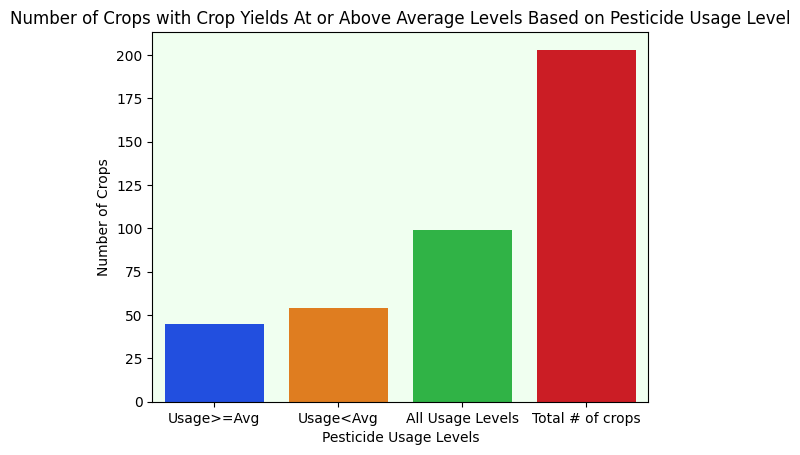

In [245]:
#Graphing Bargraph1 
barGraph1x = ['Usage>=Avg', 'Usage<Avg','All Usage Levels', 'Total # of crops']
barGraph1y = [aboveAvgPesticideAndYield_count, belowAvgPesticideAboveYield_count,aboveAvgYield_count, totalCrops_count]

barGraph1 = sns.barplot(x = barGraph1x, y = barGraph1y, palette="bright")
barGraph1.set(
    xlabel='Pesticide Usage Levels',
    ylabel='Number of Crops',
    title='Number of Crops with Crop Yields At or Above Average Levels Based on Pesticide Usage Level',
    facecolor= 'honeydew'

)

/var/folders/25/7w50mjsn2jb48hvl9dv3ss840000gn/T/ipykernel_27017/2785205199.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barGraph2 = sns.barplot(x = barGraph2x, y = barGraph2y, palette="deep")


[Text(0.5, 0, 'Pesticide Usage Levels'),
 Text(0, 0.5, 'Number of diseased crops where severity <= Mild'),
 Text(0.5, 1.0, 'Number of Diseased Crops At or Below a Mild severity Based on Pesticide Usage Levels'),
 None]

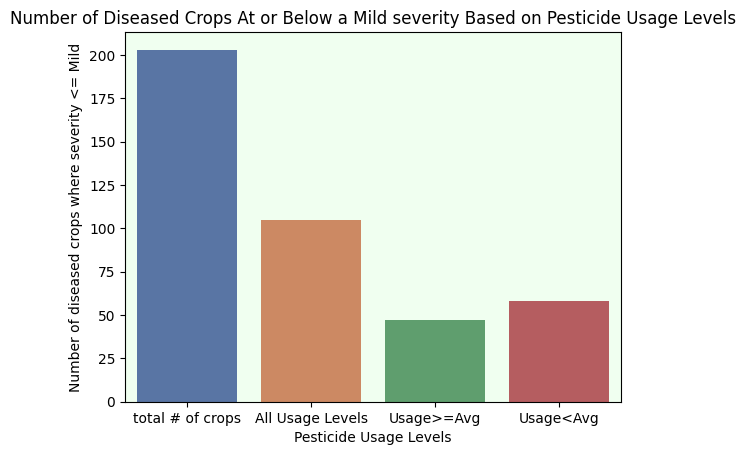

In [246]:
#Graphing barGraph2

barGraph2x = ['total # of crops','All Usage Levels', 'Usage>=Avg', 'Usage<Avg']
barGraph2y = [totalCrops_count, mildNone_count, aboveAvgPesticideBelowMild_count, belowAvgPesticideBelowMild_count]
barGraph2 = sns.barplot(x = barGraph2x, y = barGraph2y, palette="deep")
barGraph2.set(
    xlabel='Pesticide Usage Levels',
    ylabel='Number of diseased crops where severity <= Mild',
    title='Number of Diseased Crops At or Below a Mild severity Based on Pesticide Usage Levels',
    facecolor= 'honeydew'

)

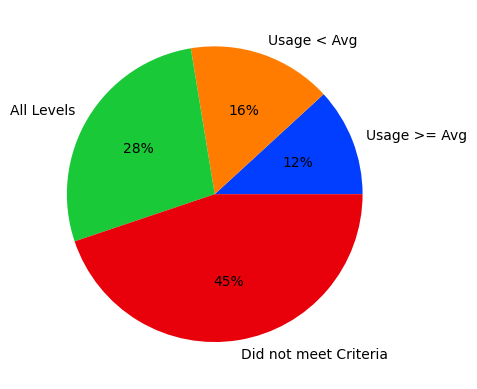

In [247]:
#Ignore chart, decided it would be better to compare as a bar graph 
#ode still visible because calulcations here are converted to bar graph in next block 
aboveAvgYield_count
pieChart1_data = [(zscore_list_length/totalCrops_count), (belowAvgPesticideYieldStatus_count/totalCrops_count), (aboveAvgYieldAndStatus_count/totalCrops_count), (1-((zscore_list_length+belowAvgPesticideYieldStatus_count+aboveAvgYieldAndStatus_count)/totalCrops_count))]
pieChart1_labels = ['Usage >= Avg','Usage < Avg', 'All Levels', 'Did not meet Criteria']
pieChart1_color = sns.color_palette("bright")
plt.pie(pieChart1_data, labels=pieChart1_labels, colors=pieChart1_color, autopct='%.0f%%')
plt.title = 'Percentage of number of crops with yields >= Avg and with Disease Status <= Mild Based on Pesticide Levels'
plt.show()


/var/folders/25/7w50mjsn2jb48hvl9dv3ss840000gn/T/ipykernel_27017/3603676774.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barGraph3 = sns.barplot(x = pieChart1_labels, y = pieChart1_data, palette="bright")


[Text(0.5, 0, 'Pesticide Usage Levels'),
 Text(0, 0.5, 'Ratio as a Decimal'),
 Text(0.5, 1.0, 'Decimal Ratio of Number of Crops with Yields At or Above Average \nAND a Diseased Crop Status of Mild or lower\n Based on Pesticide Usage Levels'),
 None]

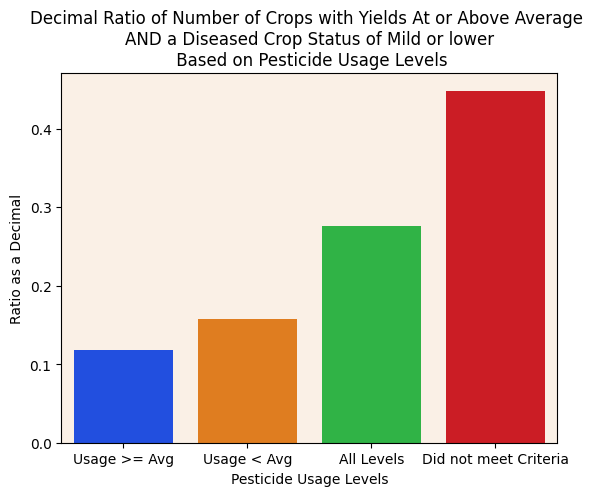

In [236]:
#Piechart 1 aas a bargraph
#bargraph 3: 
barGraph3 = sns.barplot(x = pieChart1_labels, y = pieChart1_data, palette="bright")
barGraph3.set(
    xlabel='Pesticide Usage Levels',
    ylabel='Ratio as a Decimal',
    title='Decimal Ratio of Number of Crops with Yields At or Above Average \nAND a Diseased Crop Status of Mild or lower\n Based on Pesticide Usage Levels',
    facecolor= 'linen'

)